## 1. Alternative Schedules for Step Sizes 

В этом упражнении мы рассмотрим альтернативные возможные способы задачи размера шагов для в задачах стох.оптимизации. А именно, мы рассмотрим политику выбора шагов, основанную на использовании полиномов Чебышева для минимизации квадратичной Функции. Также мы рассмотрим обобщение правила Армихо для данной задачи.

Как обычно, рассмотрим задачу минимизации,

$$\min_{w} L(w)=\mathbb{E}_{\xi} l(w, \xi)$$


К ней применим метод стохастического градиентного спуска (с батчами). Мы будем рассматривать задачу обучения [ResNet-18](https://arxiv.org/pdf/1512.03385) на датасете CIFAR-10. В качестве лосс-функции будем использовать кросс-энтропию. Соответственно, $\xi$ в нашем случае - это случайно выбираемые индексы сэмплов из выборки. 

1. **Fractal Learning Schedule** 

    a. Рассмотрим задачу квадратичной оптимизации $\min_w (\frac{1}{2} w^\top A w - b^\top w)$ с $A\in \mathbb{S}^d_{++}$ и метод градиентного спуска для нее $\{w^{t+1} = w^t - \eta^t (Aw^t-b) \}_{t=0}^{T-1}.$ Пусть $w^*$ - решение квадратичной задачи. Покажите, что $w^{T}-w^* = P(A)(w^0 - w^*),$ где $P(A) = \prod_{t=0}^{T-1} (I-\eta^t A)$
    
    b. Далее введем $p:\mathbb{R}\rightarrow \mathbb{R}$ - полином с теми же самыми коэффициентами, что и в $P(A)$ (т.е. если $P(A)=\sum\limits_{k=0}^{T-1} \alpha^k [A]^k,$ то $p(z)=\sum\limits_{k=0}^{T-1} \alpha^k [z]^k$). Покажите следующие свойства полиномов: (i) $p(0)=1;$ (ii) $p(1/\eta^t)=0$ (iii) $\|P(A)\|_2 \leq \|p\|_{\infty, A}:= \max_{\lambda\in[\lambda_{\min}(A), \lambda_{\max}(A)]} |p(\lambda)|$
        
    c. Таким образом, задавая полином $p$ степени $T$ с $T$ действительными корнями и $p(0)=1$, мы получаем GD с политикой шагов **с точностью до перестановки** для квадратичной задачи оптимизации, причем скорость сходимости его определяется нормой полинома $p$ на спектре матрицы $A$. Одним из способов является выбрать $\eta^t = 1/\lambda_{\max}(A).$ Это дает нам классический градиентный спуск с константным шагом и скоростью сходимости порядка $\kappa$. Альтернативно можно задать этот полином через полином чебышева:
    $$p(\gamma) = \mathcal{T}_T \Big(\frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}}\Big) \Big/ \mathcal{T}_T \Big(\frac{\lambda_{\max} + \lambda_{\min}}{\lambda_{\max} - \lambda_{\min}}\Big),$$
    где $\mathcal{T}_T(z)= \cos(T \arccos (z))$ - полином Чебышева степени $T$. Найдите корни полинома $p$ и покажите, что если $\gamma$ - корень полинома $p$, то $\gamma^{-1} \geq 1 / \lambda_{\max}(A)$ 
    
    d. Задавая размер шага $\{\eta^t\}$, как любую перестановку корней полинома $p$ с предыдущего шага, мы получаем политику шага в GD. Более того, предыдущий пункт показывает, что шаги даваемые полиномом Чебышева не меньше, чем лучший теоретический фиксированный шаг, что может дать существенное ускорение. Пусть $\{\gamma_t(\lambda_{\min}(A), \lambda_{\max}(A))\}_{t=1}^{T}$ - возрастающая последовательность корней полинома $p$, найденных на предыдущем шаге. Далее мы предполагаем, что $T$ есть степень 2. Рассмотрим следующую перестановку $\sigma_T : [T]\rightarrow [T]$:
    
     (i) Пусть $\sigma_1 := [1]$
        
     (ii) Тогда $\sigma_{2T} := \text{interlace}\left(\sigma_T, 2T+1-\sigma_T\right)$, где $\text{interlace}(a, b)=[a_1, b_1, a_2, b_2 \dots a_n, b_n],$ т.е. $\sigma_{2T}(i) =  \begin{cases}\sigma_{T}(i)& i \text{ mod }2=1 \\ 2T+1-\sigma_{T}(i) & i\text{ mod }2 = 0 \end{cases}$
     
     Пользуясь данной перестановкой, мы можем задать Фрактальный Чебышевский шаг: $\eta^t = \frac{1}{\gamma^{\sigma_{T(t)}}(m, M)}, t=1\dots T,$ где $m,M$ - некоторые оценки на спектр матрицы $A$, а именно $m\leq \lambda_{\min}(A) \leq \lambda_{\max}(A)\leq M$. При $t=\geq T$ будем продолжим шаг переиодическим образом, т.е. $\eta^{Tn+t} = \eta^t,$ где $n\in\mathbb{N}_0, t=1\dots T$
     
     Возьмите некоторые фиксированные $M\geq m$ и изобразите на одном графике $\eta^t,$ построенные по стратегии выше для различных $T$. Опишите, что Вы наблюдаете. 
     
     e. Для квадратичной задачи можно показать, что GD с шагом выше может сходиться, как ускоренный метод. Далее мы применим ту же самую стратегию для обучения нейронных сетей. Понятно, что $M,m$ теперь не могут быть оценками спектра матрицы, и теперь это будут гиперпараметры нашего метода. Более того, при обучении нейронной сети мы продолжим использовать SGD. Реализуйте SGD (с параметрами $m,M,T$) с политикой шагов описанной в пунктах выше.
     
     g. Рассмотрите сходимость метода на трейне и на тесте для различных параметров $m,M,T$ в сравнении с обычным SGD с константным шагом


2. **Armijo Procedure** На одном из семинаров рассматривался правило Армихо, как адаптивный подбор шага $\eta^t$, для минимизации функции $L(w)$ градиентным спуском:

    $$L(w^{t+1}) \leq L(w^t) - \beta \eta^t \|\nabla L(w^t)\|,$$

    а именно, мы начинали с некоторого шага $\overline{\eta}^t$ и делили его на два до тех пор, пока условие выше не будет выполнено (параметр $\beta\in(0,1)$). Для стохастического градиентного спуска можно похожее правило:
    
    $$l(w^{t+1}, \color{red}{\xi^t}) \leq l(w^t, \color{red}{\xi^t}) - \beta \eta^t \|\nabla l(w^t, \color{red}{\xi^t})\|$$

    Т.е. на каждой итерации мы генерируем некоторый батч и рассматриваем правило Армихо для соответсвующей ей функции $l(w^{t+1}, \color{red}{\xi^t})$. Заметим, что данную процедуру мы можем использовать только в том случае, если мы можем "переиспользовать" случайность $\color{red}{\xi^t}$. Данный класс задач существенно меньше, чем задача стохастической оптимизации, однако данный подход применим к обучению нейронных сетей, в которых эта случайность есть выбор сэмплов на каждой итерации, что полностью в наших руках.
    
    a. Оцените сложность SGD с правилом Армихо в сравнении с обычным SGD с константным шагом
    
    b. Реализуйте SGD с правилом Армихо с учетом того различных вариаций начала подбора шага $\overline{\eta}^t$ (i) предыдущий немного увеличенный шаг $\overline{\eta}^t = \gamma \eta^{t-1}$ с $\gamma>0$; (ii) Всегда начинается с некоторой константы $\overline{\eta}^t = \eta.$
    
    c. Сравните реализованные стратегии с предыдущего шага и SGD с постоянным шагом. Обратите внимание также на время, требуемое на одну итерацию. Покажите, как меняется шаг от итерации к итерации в шаге 2.b 

3. Сравните следующие методы

    a. SGD с Фрактальным Чебышевским Шагом из п.1
    
    b. SGD с Armijo из п.2
    
    с. SGD с постоянным шагом
    
    d. SGD с Cosine Annealing
    
    e. SGD with momentum
    
    g. Adam
    
*Замечание:* При реализации стратегий для подбора шага естественным будет использование ```torch.optim.lr_scheduler```. Также рекомендуем на время отладки ваших методов уменьшить размер датасета в обучающей выборке.

## Решения

1. **Fractal learning schedule**

   a. 
      Для решения задачи $w^*$ справедливо, что градиент равен нулю. Следовательно, $Aw^* = b$. Тогда
      $$ w^{t+1} - w^* = w^t - \eta^t (Aw^t - b) - w^* = (I - \eta^t A)w^t + \eta^t b - w^* $$
      $$ = (I - \eta^t A)w^t + \eta^t Aw^* - w^* =  (I - \eta^t A)(w^t - w^*) $$
      Расписав это рекурсивно для $T$ шагов, получим
      $$ w^{T} - w^* = P(A)(w^0 - w^*) $$

  
   c. 
      Найдём корни полинома Чебышева:
      $$ p(\gamma) = \mathcal{T}_T \Big(\frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}}\Big) \Big/ \mathcal{T}_T \Big(\frac{\lambda_{\max} + \lambda_{\min}}{\lambda_{\max} - \lambda_{\min}}\Big) = 0 \iff $$
      $$ \mathcal{T}_T \Big(\frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}}\Big) = 0 \iff $$
      $$ \cos \left( T \arccos \left( \frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}} \right) \right) = 0 \iff $$
      $$ \frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}} = \cos(\pi \frac{1/2 + n}{T}), \quad \frac{\lambda_{\max} + \lambda_{\min} - 2\gamma}{\lambda_{\max} - \lambda_{\min}} \in [-1, 1], \quad n \in \mathbb{R} $$
      Откуда получаем выражение для $2\gamma$:
      $$ 2\gamma = \lambda_{max} + \lambda_{min} - (\lambda_{max} - \lambda_{min})\cos(\pi \frac{1/2 + n}{T}) $$
      Тогда различных корней будет ровно $T$ штук, и они равномерно распределены на отрезке $[\lambda_{\min}, \lambda_{\max}]$.

      Подставим условие $\gamma^{-1} \geq 1 / \lambda_{\max}(A)$:
      $$ \lambda_{max} + \lambda_{min} - (\lambda_{max} - \lambda_{min})\cos(\pi \frac{1/2 + n}{T}) \leq 2\lambda_{max} $$
      Выражение слева принимает максимальное значение при $\cos = -1$:
      $$ \lambda_{max} + \lambda_{min} + \lambda_{max} - \lambda_{min} \leq 2\lambda_{max} \iff 2\lambda_{max} \leq 2\lambda_{max}, $$
      что выполняется для любого $\gamma$ из области определения.

   d. 
      Ниже представлен функционал для расчёта шагов и отрисовки соответствующих графиков.

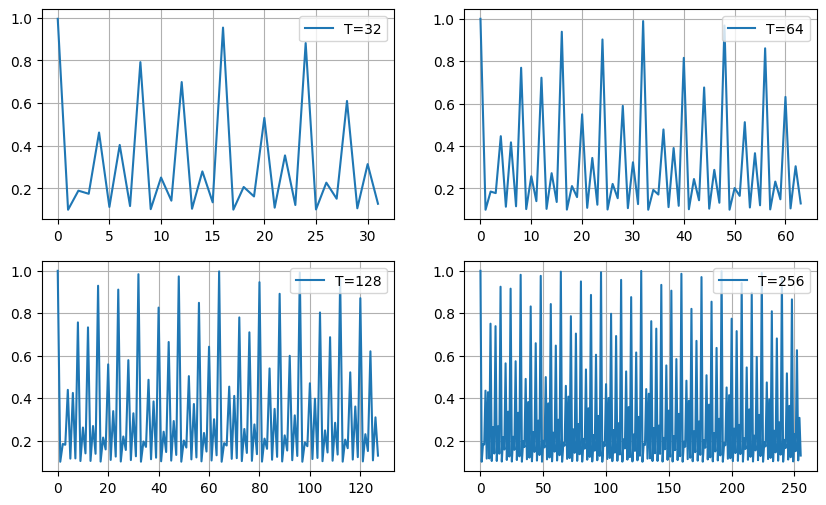

In [37]:
from typing import List, Tuple, Callable, Literal, Optional, Any

import numpy as np
from matplotlib import pyplot as plt


def get_schedule(T: int) -> List[int]:
    if T == 1:
        return [0]
    else:
        sub_schedule = get_schedule(T // 2)
        schedule = []
        for i in range(len(sub_schedule)):
            schedule.append(sub_schedule[i])
            schedule.append(T - 1 - sub_schedule[i])

        return schedule


def get_step_strategy(T: int, m: float, M: float) -> List[float]:
    schedule = get_schedule(T)
    roots = [(m + M - (M - m) * np.cos(np.pi * (0.5 + t) / T)) / 2 for t in schedule]
    return [1 / root for root in roots]


fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
ax = ax.flatten()
for i, T in enumerate([32, 64, 128, 256]):
    ax[i].plot(get_step_strategy(T, 1, 10), label=f"T={T}")
    ax[i].legend(loc="upper right")
    ax[i].grid()
plt.show()

Графики имеют хаотичный вид, также наблюдается периодические скачки (большие значения размера шага)

e. Ниже - реализация `LRScheduler` для выбора шагов из корней полинома Чебышева

In [38]:
from torch import optim


class FractalScheduler(optim.lr_scheduler.LRScheduler):
    def __init__(self, optimizer: optim.Optimizer, T: int, m: float, M: float):
        self.T = T
        self.m = m
        self.M = M
        self.schedule = get_step_strategy(T, m, M)
        super().__init__(optimizer)

    def get_lr(self):
        return [
            base_lr * self.schedule[self.last_epoch % len(self.schedule)]
            for base_lr in self.base_lrs
        ]


class ConstantScheduler(optim.lr_scheduler.LRScheduler):
    def __init__(self, optimizer: optim.Optimizer):
        super().__init__(optimizer)

    def get_lr(self):
        return self.base_lrs

g. Далее представлен код для сравнение различных выборов размера шага на трейне и тесте. Были протестированы несколько различных параметров $m, M, T$ для `FractalScheduler`.

In [39]:
import random
from tqdm import tqdm
import time

import torch
from torch import nn
import torchvision

from torchvision.models import resnet18
import torchvision.transforms as transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

In [40]:
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

# Download and Preprocess  Dataset for Train

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True)

test_loader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [41]:
def get_model(device: str):
    model = resnet18()
    model.fc = nn.Linear(512, 10)
    model.to(device)
    return model

In [42]:
def test_optimizer(
    model: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler.LRScheduler,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    num_epochs: int = 3,
    device: str = "cuda",
) -> Tuple[List[float], float, float]:
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    model.train()
    t_start = time.time()
    for epoch in range(num_epochs):
        train_loop = tqdm(train_loader)
        for x, y in train_loop:
            x = x.to(device)
            y = y.to(device)

            def closure():
                output = model(x)
                loss = criterion(output, y)
                try:
                    loss.backward()
                except RuntimeError:
                    pass
                return loss

            output = model(x)
            optimizer.zero_grad()
            loss = criterion(output, y)
            loss.backward()
            optimizer.step(closure)
            scheduler.step()
            loss_history.append(loss.item())

            train_loop.set_postfix(loss=loss_history[-1])
    t_end = time.time()
    model.eval()
    correct_preds = 0
    samples = 0
    eval_loop = tqdm(test_loader)
    for x, y in eval_loop:
        x = x.to(device)
        y = y.to(device)
        with torch.no_grad():
            output = model(x)
        correct_preds += (output.argmax(dim=1) == y).sum().item()
        samples += len(y)
        eval_loop.set_postfix(accuracy=correct_preds / samples)

    return loss_history, correct_preds / samples, t_end - t_start

In [43]:
# SGD with constant learning rate
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = ConstantScheduler(optimizer)
history_orig, acc_orig, time_orig = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# SGD with fractal learning rate, T=512, m=2, M=4
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = FractalScheduler(optimizer, 512, 2, 4)
history_fractal_1, acc_fractal_1, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# SGD with fractal learning rate, T=128, m=1, M=10
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = FractalScheduler(optimizer, 128, 1, 10)
history_fractal_2, acc_fractal_2, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# SGD with fractal learning rate, T=1024, m=4, M=5
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = FractalScheduler(optimizer, 1024, 4, 5)
history_fractal_3, acc_fractal_3, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

100%|██████████| 20/20 [00:01<00:00, 14.02it/s, accuracy=0.499]


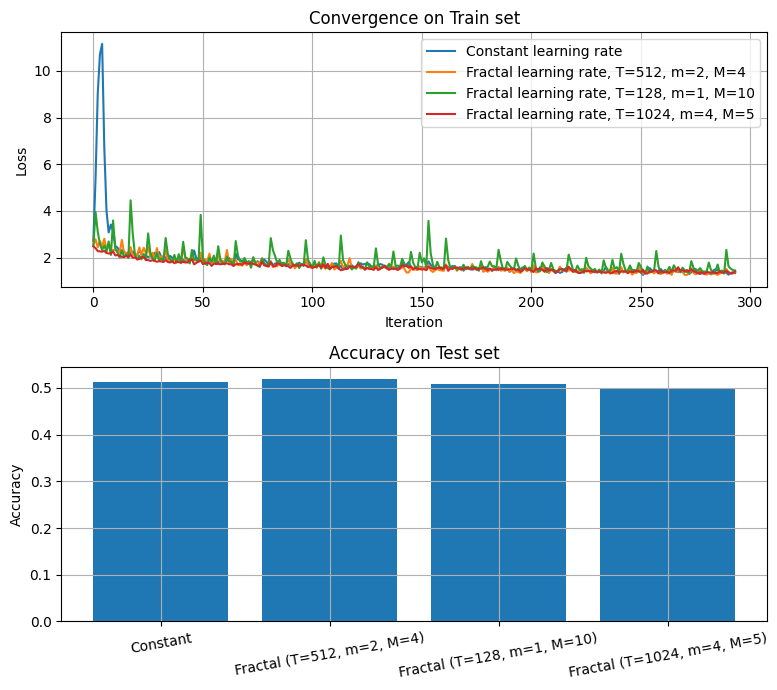

In [44]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(history_orig, label="Constant learning rate")
ax[0].plot(history_fractal_1, label="Fractal learning rate, T=512, m=2, M=4")
ax[0].plot(history_fractal_2, label="Fractal learning rate, T=128, m=1, M=10")
ax[0].plot(history_fractal_3, label="Fractal learning rate, T=1024, m=4, M=5")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "Constant",
        "Fractal (T=512, m=2, M=4)",
        "Fractal (T=128, m=1, M=10)",
        "Fractal (T=1024, m=4, M=5)",
    ],
    [acc_orig, acc_fractal_1, acc_fractal_2, acc_fractal_3],
)

ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy on Test set")
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=10)
ax[1].grid()

plt.tight_layout()
plt.show()

Как показывают графики, некоторые конфигурации для `FractalScheduler` дают небольшой выигрыш в качестве на тесте, однако в целом результаты схожи с обычным SGD. 

2. **Armijo Procedure**
   
    a. Правило Армихо подразумевает итеративное уменьшение шага до тех пор, пока значение лосса не станет ниже определённого порога. Для оценки сложности правила Армихо по сравнению с SGD, обозначим за $O(f)$ сложность подсчёта целевой функции на одном примере, за $O(g)$ сложность подсчёта градиента на одном примере, за $B$ - количество примеров в батче, а за $\eta_{start}, \eta_{end}$ - начальное и конечное значения шага для правила Армихо. Тогда сложность одного шага SGD будет $O(gB)$, а сложность одного шага с правилом Армихо будет $O(gB + fB\log_{\gamma} \frac{\eta_{start}}{\eta_{end}})$, так как мы пересчитываем целевую функцию после каждого уменьшения шага.

    b. Ниже представлена реализация правила Армихо как `Optimizer`

In [50]:
class ArmijoSGD(optim.Optimizer):
    def __init__(
        self,
        params,
        lr: float,
        beta: float,
        gamma: float,
        loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        initial_step_size: Literal["constant", "previous"],
        step_size_incr: float = 1.2,
    ):
        self.params = params
        self.lr = lr
        self.beta = beta
        self.gamma = gamma
        self.loss_fn = loss_fn
        self.initial_step_size = initial_step_size
        self.step_size_incr = step_size_incr
        super().__init__(
            self.params,
            dict(
                lr=lr,
                beta=beta,
                gamma=gamma,
                loss_fn=loss_fn,
                initial_step_size=initial_step_size,
            ),
        )

    def _update_weights(self, coef: float):
        for group in self.param_groups:
            for param in group["params"]:
                param.data.add_(param.grad, alpha=coef)

    def _get_grad_norm(self):
        return torch.sqrt(
            torch.sum(
                torch.tensor(
                    [
                        torch.norm(param.grad) ** 2
                        for group in self.param_groups
                        for param in group["params"]
                        if param.grad is not None
                    ]
                )
            )
        )

    def step(self, closure: Optional[Callable[[], float]] = None):
        with torch.no_grad():
            initial_loss = closure()
            grad_norm = self._get_grad_norm()

        step_size = self.lr
        self._update_weights(-step_size)

        with torch.no_grad():
            while closure() > initial_loss - self.beta * step_size * grad_norm:
                step_size *= self.gamma
                self._update_weights((1 - self.gamma) * step_size)

                if step_size < 1e-8:
                    break

        if self.initial_step_size == "previous":
            self.lr = step_size * 1.2

        return step_size

In [51]:
# Armijo rule with constant step size
model = get_model(device)
armijo_1 = ArmijoSGD(
    params=model.parameters(),
    lr=0.1,
    beta=0.5,
    gamma=0.8,
    loss_fn=nn.CrossEntropyLoss(),
    initial_step_size="constant",
)
scheduler = ConstantScheduler(armijo_1)

history_armijo_1, acc_armijo_1, _ = test_optimizer(
    model,
    armijo_1,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# Armijo rule with previous step size
model = get_model(device)
armijo_2 = ArmijoSGD(
    params=model.parameters(),
    lr=0.1,
    beta=0.5,
    gamma=0.8,
    loss_fn=nn.CrossEntropyLoss(),
    initial_step_size="previous",
)
scheduler = ConstantScheduler(armijo_2)

history_armijo_2, acc_armijo_2, _ = test_optimizer(
    model,
    armijo_2,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

100%|██████████| 20/20 [00:01<00:00, 13.79it/s, accuracy=0.539]


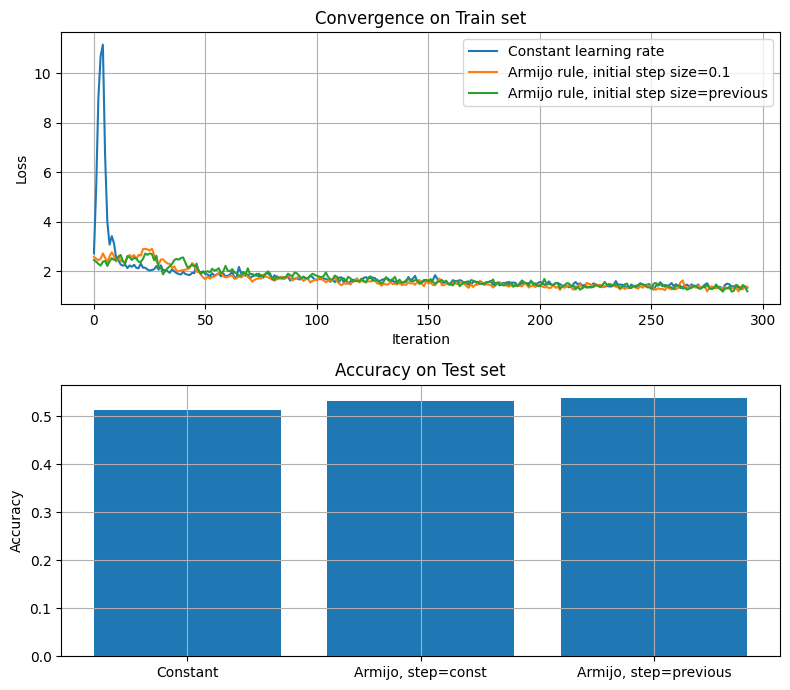

In [52]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(history_orig, label="Constant learning rate")
ax[0].plot(history_armijo_1, label="Armijo rule, initial step size=0.1")
ax[0].plot(history_armijo_2, label="Armijo rule, initial step size=previous")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "Constant",
        "Armijo, step=const",
        "Armijo, step=previous",
    ],
    [acc_orig, acc_armijo_1, acc_armijo_2],
)

ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy on Test set")
ax[1].set_xticks(ax[1].get_xticks())
ax[1].grid()

plt.tight_layout()
plt.show()

Графики показывают незначительное преимущество правила Армихо над обычным SGD, однако в целом результаты схожи. Также отметим, что на трейне правило Армихо с постоянным шагом сходится быстрее немного быстрее.

c. сравним время и размеры шагов на разных итерациях для правила Армихо:

In [54]:
def test_step_size_time(
    model: nn.Module,
    optimizer: ArmijoSGD,
    train_loader: torch.utils.data.DataLoader,
    num_epochs: int = 3,
    device: str = "cuda",
) -> Tuple[List[float], List[float]]:
    criterion = nn.CrossEntropyLoss()
    times = []
    step_sizes = []

    model.train()
    for epoch in range(num_epochs):
        train_loop = tqdm(train_loader)
        for x, y in train_loop:
            x = x.to(device)
            y = y.to(device)

            def closure():
                output = model(x)
                loss = criterion(output, y)
                try:
                    loss.backward()
                except RuntimeError:
                    pass
                return loss

            output = model(x)
            optimizer.zero_grad()
            loss = criterion(output, y)
            loss.backward()
            t_start = time.time()
            step_size = optimizer.step(closure)
            times.append(time.time() - t_start)
            step_sizes.append(step_size)
            scheduler.step()
            train_loop.set_postfix(loss=loss.item())

    return step_sizes, times


model = get_model(device)
optimizer = ArmijoSGD(
    params=model.parameters(),
    lr=0.1,
    beta=0.5,
    gamma=0.8,
    loss_fn=nn.CrossEntropyLoss(),
    initial_step_size="previous",
)
step_sizes_previous, times_previous = test_step_size_time(
    model,
    optimizer,
    train_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = ArmijoSGD(
    params=model.parameters(),
    lr=0.1,
    beta=0.5,
    gamma=0.8,
    loss_fn=nn.CrossEntropyLoss(),
    initial_step_size="constant",
)
step_sizes_constant, times_constant = test_step_size_time(
    model,
    optimizer,
    train_loader,
)

100%|██████████| 98/98 [00:15<00:00,  6.13it/s, loss=1.34]


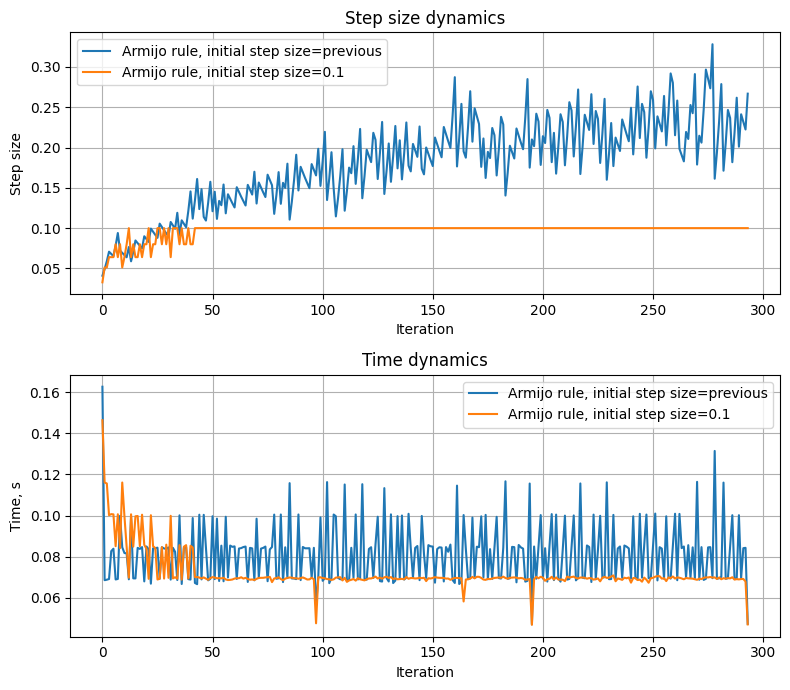

In [55]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(step_sizes_previous, label="Armijo rule, initial step size=previous")
ax[0].plot(step_sizes_constant, label="Armijo rule, initial step size=0.1")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Step size")
ax[0].set_title("Step size dynamics")
ax[0].grid()

ax[1].plot(times_previous, label="Armijo rule, initial step size=previous")
ax[1].plot(times_constant, label="Armijo rule, initial step size=0.1")
ax[1].legend(loc="best")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Time, s")
ax[1].set_title("Time dynamics")
ax[1].grid()

plt.tight_layout()
plt.show()

Из графика видно, что изначальный выбор шага как константа немного быстрее на отдельных итерациях, но учёт предыдущего шага "ослабляет" ограничение сверху на размер шага, что способствует более быстрой сходимости. 

3. Ниже представлено сравнение некоторых методов оптимизации на трейне и тесте.

In [56]:
# SGD with constant learning rate
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = FractalScheduler(optimizer, 1024, 4, 8)
history_fractal, acc_fractal, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# Armijo rule with constant step size
model = get_model(device)
optimizer = ArmijoSGD(
    params=model.parameters(),
    lr=0.1,
    beta=0.5,
    gamma=0.8,
    loss_fn=nn.CrossEntropyLoss(),
    initial_step_size="constant",
)
scheduler = ConstantScheduler(optimizer)
history_armijo, acc_armijo, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# Armijo rule with previous step size
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = ConstantScheduler(optimizer)
history_constant, acc_constant, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# SGD with cosine annealing learning rate
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=256)
history_cosine, acc_cosine, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# SGD with momentum
model = get_model(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = ConstantScheduler(optimizer)
history_momentum, acc_momentum, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

# Adam
model = get_model(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ConstantScheduler(optimizer)
history_adam, acc_adam, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

100%|██████████| 20/20 [00:01<00:00, 14.45it/s, accuracy=0.637]


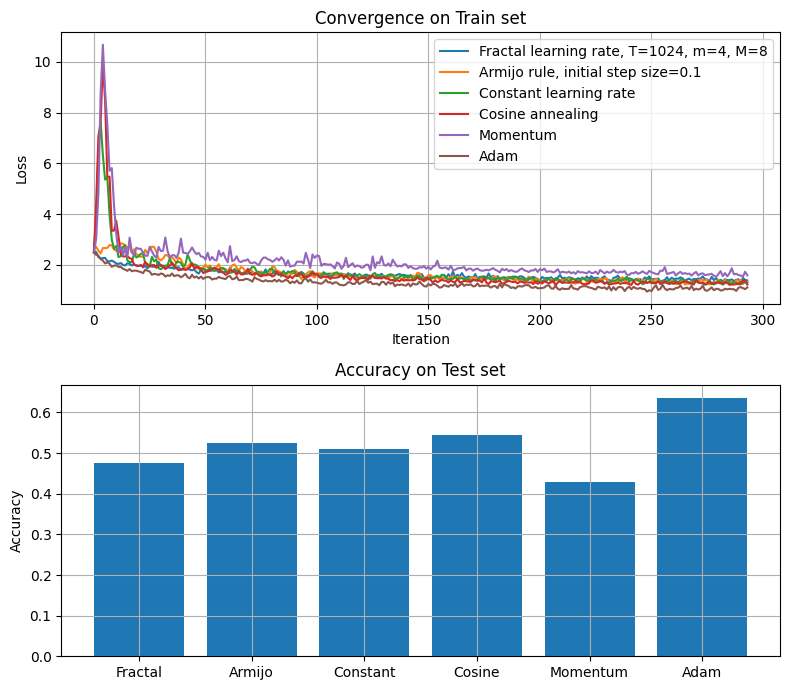

In [57]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(history_fractal, label="Fractal learning rate, T=1024, m=4, M=8")
ax[0].plot(history_armijo, label="Armijo rule, initial step size=0.1")
ax[0].plot(history_constant, label="Constant learning rate")
ax[0].plot(history_cosine, label="Cosine annealing")
ax[0].plot(history_momentum, label="Momentum")
ax[0].plot(history_adam, label="Adam")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "Fractal",
        "Armijo",
        "Constant",
        "Cosine",
        "Momentum",
        "Adam",
    ],
    [acc_fractal, acc_armijo, acc_constant, acc_cosine, acc_momentum, acc_adam],
)

ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy on Test set")
ax[1].set_xticks(ax[1].get_xticks())
ax[1].grid()

plt.tight_layout()
plt.show()

## 2. Sharpness Aware Optimization

Модель, получаемая при помощи методов типа SGD, обладает рядом проблем с устойчивостью и обобщением результатов. Это упражнение посвящено одному из способов решения данной проблемы. Все эксперименты будут проводиться на той же задаче, что и в предыдущем упражнении - обучение ResNet-18 на CIFAR-10.

Пусть у нас есть некоторая модель с параметрами $\mathbf{w}\in \mathcal{W}\subseteq \mathbb{R}^d$. Эта модель должна преобразовывать вход $\mathbf{x} \in \mathcal{X}$ в $\mathbf{y}\in \mathcal{Y}$. Качество этого преобразования будет задаваться функцией потерь $\ell:\mathcal{W}\times \mathcal{X}\times \mathcal{Y} \rightarrow \mathbb{R}$.

Предполагая, что все данные приходят из некоторого (неизвестного) распределения $\mathscr{D}$ мы можем записать следующую задачу минимизации:

$$\min L_{\mathscr{D}}(\mathbf{w}) =\mathbb{E}_{\mathbf{x}, \mathbf{y}\sim \mathscr{D}} \ell(\mathbf{w}, \mathbf{x}, \mathbf{y})$$

Однако, на практике у нас нет доступа к распределению $\mathcal{D},$ и в таком случае задача заменяется на задачу минимизации эмпирического риска на некоторой обучающей выборке $\mathcal{S}\subseteq \mathcal{X}\times \mathcal{Y}$ i.i.d. случайный величин:

$$\min L_{\mathcal{S}}(\mathbf{w}) =\frac{1}{|\mathcal{S}|} \sum\limits_{\mathbf{x}, \mathbf{y}\in \mathcal{S}} \ell(\mathbf{w}, \mathbf{x}, \mathbf{y})$$

Классическим подходом для такого рода задач являются методы по типу стохастического градиентного метода, которые рассматривают задачу выше, как задачу минимизации математического ожидания с равномерным распределением на $\mathcal{S}$. Однако эти методы не учитывают структуру исходной задачи, что приводит к тому, что решение задачи с множеством $\mathcal{S}$ может быть "плохим" решением для задачи с распределением $\mathscr{D}.$ В этом задании мы рассмотрим один из способов решить эту проблему.

При некоторых условиях на распределение $\mathscr{D}$ и свойства функции $\ell$ можно показать следующую оценку:
$$L_{\mathscr{D}}(\mathbf{w}) \leq \max_{\varepsilon: \|\varepsilon\|_p\leq \rho} L_{\mathcal{S}}(\mathbf{w} + \varepsilon) + \frac{\lambda_0}{\rho} \|\textbf{w}\|^2 + O(1),$$
где $\lambda_0$ - некоторая величина, зависящая от характеристик распределения и функции потерь. Из оценки сверху следует идея минимизации следующей функции потерь:

$$\min_{\mathbf{w}} \left[L^{\text{SAM}}_{\mathcal{S}}(\mathbf{w}) + \lambda \|\textbf{w}\|^2\right],\quad\text{где}L^{\text{SAM}}_{\mathcal{S}}(\mathbf{w})=\max_{\varepsilon: \|\varepsilon\|_p\leq \rho} L_{\mathcal{S}}(\mathbf{w}+\varepsilon)$$
где $p\in (1,\infty), \rho, \lambda \in \mathbb{R}_+$ - гиперпараметры данного подхода. Далее мы будем предполагать, что $L^{\text{SAM}}_{\mathcal{S}}$ дифференцируема.

1. Для запуска градиента функции выше, нам необходимо найти $\nabla_{\textbf{w}} L^{\text{SAM}}_{\mathcal{S}} ,$ где $$\varepsilon^*(\mathbf{w}) = \arg\max _{\varepsilon: \|\varepsilon\|_p\leq \rho} L_{\mathcal{S}}(\mathbf{w}+\varepsilon)$$. Однако процедура нахождения может быть достаточно тяжелой и поэтому предлагается заменить $\varepsilon^*(\mathbf{w})$ на $\hat{\varepsilon}(\mathbf{w}):$ $$\hat{\varepsilon}(\mathbf{w})=\arg\max _{\varepsilon: \|\varepsilon\|_p\leq \rho} \langle \nabla L_{\mathcal{S}}(\mathbf{w}), \varepsilon\rangle.$$ 
    
    Объясните интуицию такой аппроксимации и выведите в явном виде выражение для $\hat{\varepsilon}(\mathbf{w})$ через $\nabla L_{\mathcal{S}}(\mathbf{w}), \rho, p$ 

2. В таком случае $\nabla_{\textbf{w}} L_{\mathcal{S}}(\mathbf{w}) \approx \nabla_{\mathbf{w}} L_{\mathcal{S}}(\mathbf{w} + \hat{\varepsilon}(\mathbf{w}))$. Выведите $\nabla_{\mathbf{w}} L_{\mathcal{S}}(\mathbf{w} + \hat{\varepsilon}(\mathbf{w})),$ используя якобиан $\frac{\partial \hat{\varepsilon}(\mathbf{w})}{\partial \mathbf{w}}$.

3. Градиент $\nabla_{\mathbf{w}} L_{\mathcal{S}}(\mathbf{w} + \hat{\varepsilon}(\mathbf{w}))$ может быть вычислен при помощи автоматического дифференцирования в ```torch```, однако можно сэкономить вычисления, игнорируя зависимость $\hat{\varepsilon}(\mathbf{w}),$ т.е. использовать $\nabla_{\textbf{w}} L^{\text{}}_{\mathcal{S}} ({\mathbf{w}})|_{\hat{\mathbf{w}}=\mathbf{w} + \hat{\varepsilon}(\mathbf{w})}$ вместо  $\nabla_{\mathbf{w}} L_{\mathcal{S}}(\mathbf{w} + \hat{\varepsilon}(\mathbf{w}))$ (вычисляем $\hat{\varepsilon}(\mathbf{w})$ и далее не дифференцируем по нему). Это дает нам два подхода для Sharpness Aware Minimization. В качестве $\mathcal{S}$ на каждой итерации мы будем использовать батч $\mathcal{B}$ на каждой новой итерации. Какое количество вычислений градиентов требуется на одной итерации для каждого из этих способов?

4. Реализуйте Sharpness Aware Minimization method (**SAM**), т.е. обучение по батчам при помощи SGD, где градиент считается по формуле $\nabla_{\textbf{w}} L^{\text{}}_{\mathcal{S}} ({\mathbf{w}})|_{\hat{\mathbf{w}}=\mathbf{w} + \hat{\varepsilon}(\mathbf{w})}$ из предыдущего пункта

5. Исследуйте зависимость от параметров $\rho$ и $p$ на скорость сходимости и на качество на валидационной выборке. Выберите лучшие значения и далее используйте их.

6. Реализуйте второй способ вычисления градиента $\nabla_{\mathbf{w}} L_{\mathcal{S}}(\mathbf{w} + \hat{\varepsilon}(\mathbf{w}))$ в SAM, и сравните по времени и результирующему качеству этот метод и метод из п.4

6. Сравните качество на тестовой выборке для SGD и SAM из п.4

7. SAM должен быть устойчив к "плохо" сгенерированным данным. Проведите такой же эксперимент, как в пункте 6, но предварительно заменив некоторую долю меток $\mathbf{y}$ на случайные метки. Проварьируйте эту долю (20%, 40%, 60%) и сравните качество моделей  на тесте после обучения на таких данных при помощи SGD и SAM

8.  Реализуйте Sharpness Aware Minimization method (SAM), т.е. обучение по батчам при помощи **Adam** и сравните с обычным методом Adam в сеттинге пунктов 6 и 7. Наблюдается ли улучшение в таком случае?

## Решения

1.  Аппроксимация Тейлора для $L_{\mathcal{S}} (\mathbf{w} + \varepsilon)$:
    $$ L_{\mathcal{S}} (\mathbf{w} + \varepsilon) = L_{\mathcal{S}} (\mathbf{w}) + \langle \nabla L_{\mathcal{S}} (\mathbf{w}), \varepsilon \rangle + O(\|\varepsilon\|^2) $$
    Тогда справедливо:
    $$ \argmax_{\varepsilon: \|\varepsilon\|_p \leq \rho} L_{\mathcal{S}} (\mathbf{w} + \varepsilon) \approx \argmax \left( L_{\mathcal{S}} (\mathbf{w}) + \langle \nabla L_{\mathcal{S}} (\mathbf{w}), \varepsilon \rangle \right) = \argmax_{\varepsilon: \|\varepsilon\|_p \leq \rho} \left( \langle \nabla L_{\mathcal{S}} (\mathbf{w}), \varepsilon \rangle \right) $$

    Найдём максимум этой функции, для этого запишем лагранжиан:
    $$ \mathcal{L} = -\langle \nabla L_{\mathcal{S}} (\mathbf{w}), \varepsilon \rangle + \lambda (\|\varepsilon\|_p - \rho) $$
    
    Обозначим $\mathbf{g} = \nabla L_{\mathcal{S}} (w)$, тогда условие оптимальности примет вид условия оптимальности:
    $$ \frac{\partial \mathcal{L}}{\partial \varepsilon_i} = 0 \iff -\mathbf{g}_i + \lambda \frac{|\varepsilon_i|^{p-1} \mathrm{sign} (\varepsilon_i)}{\|\varepsilon\|_p^{p-1}} = 0 \iff \varepsilon_i = \left( \frac{|\mathbf{g}_i| \rho^{p-1}}{\lambda} \right)^{\frac{1}{1-p}} \mathrm{sign} (\mathbf{g}_i) $$
    так как для максимума этой функции норма $\|\varepsilon\|_p = \rho$. Обозначим сопряжённую норму $q = \frac{p}{p-1}$, и запишем сумму $\varepsilon_i$:
    $$ |\varepsilon_i|^p = \left( \frac{|\mathbf{g}_i| \rho^{p-1}}{\lambda} \right)^{q} \Longrightarrow \|\varepsilon\|_p = \left( \sum_i |\varepsilon_i|^p \right)^{\frac{1}{p}} = \left( \frac{\rho^{p-1}}{\lambda} \right)^{\frac{p}{q}} \|\mathbf{g}\|_q^{\frac{p}{q}} $$
    Подставив $\rho = \| \varepsilon \|_p$, получим:
    $$ \rho = \frac{\rho}{\lambda^{\frac{1}{p-1}}} \|\mathbf{g}\|_q^{\frac{1}{p-1}} \iff \|\mathbf{g}\|_q = \lambda $$
    Подставим это в условие оптимальности:
    $$ \varepsilon_i = \mathrm{sign} (\mathbf{g}_i) \left( \frac{|\mathbf{g}_i| \rho^{p-1}}{\|\mathbf{g}\|_q} \right)^{\frac{1}{1-p}}  = \rho \cdot \mathrm{sign} (\mathbf{g}_i)\left( \frac{|\mathbf{g}_i|}{\|\mathbf{g}\|_q} \right)^{\frac{1}{1-p}} = \rho \cdot \mathrm{sign} (\mathbf{g}_i) \frac{|\mathbf{g}_i|^{q-1}}{\|\mathbf{g}\|_q^{q-1}} $$

2.  Продифференцируем данную функцию:
    $$ \nabla_{\mathbf{w}} L_{\mathcal{S}} (\mathbf{w} + \varepsilon(\mathbf{w})) = \nabla L_{\mathcal{S}} (\mathbf{w} + \varepsilon(\mathbf{w})) \left( I + \frac{\partial \hat{\varepsilon}(\mathbf{w})}{\partial \mathbf{w}} \right) $$

3.  Для вычисления градиента с учётом функции $\hat{\varepsilon}(\mathbf{w})$ потребуется $O(d^2)$ операций, где $d$ - размерность $\mathbf{w}$, так как необходимо вычислять гессиан этой квадратичной размерности. Для вычисления градиента без учёта $\hat{\varepsilon}(\mathbf{w})$ потребуется $O(d)$ операций. 

4. Ниже представлена реализация `SAM` с регулируемыми параметрами $\rho, p$, а также опцией для подсчёта градиента в точке $\mathbf{w} + \hat{\varepsilon}(\mathbf{w})$ или $\mathbf{w}$
   
 

In [15]:
class SAM(torch.optim.Optimizer):
    def __init__(
        self,
        params,
        base_optimizer_init: Callable,
        p: float = 2,
        rho: float = 0.05,
        approx_grad: bool = True,
        **kwargs,
    ):
        self.p = p
        self.q = p / (p - 1)
        self.rho = rho
        self.approx_grad = approx_grad
        super(SAM, self).__init__(
            params, dict(p=p, rho=rho, approx_grad=approx_grad, **kwargs)
        )

        self.base_optimizer = base_optimizer_init(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    def _add_eps(self):
        scale = self.rho / (self._get_grad_norm() + 1e-12)
        for group in self.param_groups:
            for param in group["params"]:
                if param.grad is None:
                    continue
                grad = param.grad
                step = torch.sign(grad) * torch.pow(torch.abs(grad), self.q - 1)
                param.data.add_(step, alpha=-scale)

    def step(self, closure: Callable[[], torch.Tensor]):
        if self.approx_grad:
            self._add_eps()
            self.base_optimizer.step()
        else:
            self._add_eps()
            closure()
            self.base_optimizer.step()

    def _get_grad_norm(self):
        grad_vec = torch.cat(
            [
                torch.flatten(param.grad)
                for group in self.param_groups
                for param in group["params"]
                if param.grad is not None
            ]
        )
        return torch.norm(grad_vec, p=self.q - 1)

5. Ниже - код некоторых экспериментальных значений $\rho, p$ для `SAM` на трейне и тесте, нужный для выявления наилучших параметров

In [ ]:
model = get_model(device)
optimizer = SAM(model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.2, approx_grad=True)
scheduler = ConstantScheduler(optimizer)
history_sam_1, acc_sam_1, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
history_sam_2, acc_sam_2, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(model.parameters(), optim.SGD, lr=0.1, p=4, rho=0.05, approx_grad=True)
scheduler = ConstantScheduler(optimizer)
history_sam_3, acc_sam_3, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(model.parameters(), optim.SGD, lr=0.1, p=3, rho=0.1, approx_grad=True)
scheduler = ConstantScheduler(optimizer)
history_sam_4, acc_sam_4, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(model.parameters(), optim.SGD, lr=0.1, p=2, rho=0.01, approx_grad=True)
scheduler = ConstantScheduler(optimizer)
history_sam_5, acc_sam_5, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

100%|██████████| 20/20 [00:01<00:00, 14.03it/s, accuracy=0.481]


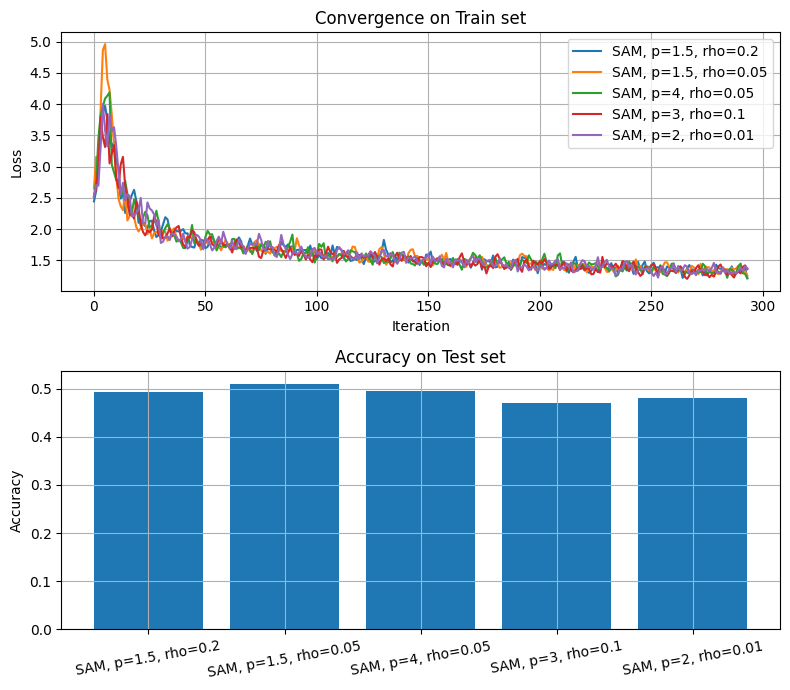

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(history_sam_1, label="SAM, p=1.5, rho=0.2")
ax[0].plot(history_sam_2, label="SAM, p=1.5, rho=0.05")
ax[0].plot(history_sam_3, label="SAM, p=4, rho=0.05")
ax[0].plot(history_sam_4, label="SAM, p=3, rho=0.1")
ax[0].plot(history_sam_5, label="SAM, p=2, rho=0.01")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "SAM, p=1.5, rho=0.2",
        "SAM, p=1.5, rho=0.05",
        "SAM, p=4, rho=0.05",
        "SAM, p=3, rho=0.1",
        "SAM, p=2, rho=0.01",
    ],
    [acc_sam_1, acc_sam_2, acc_sam_3, acc_sam_4, acc_sam_5],
)

ax[1].set_ylabel("Accuracy")
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=10)
ax[1].set_title("Accuracy on Test set")
ax[1].grid()

plt.tight_layout()
plt.show()

Будем использовать следующие параметры: $\rho = 0.05, p = 1.5$, так как они показывают наилучшие результаты на тестовой выборке.

6, 7. Ниже - код для сравнения двух способов вычисления градиента в `SAM` на трейне и тесте по времени, а также сравнение сходимости с `SGD`

In [ ]:
model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=False
)
scheduler = ConstantScheduler(optimizer)
history_sam_exact_grad, acc_sam_exact_grad, time_sam_exact_grad = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
history_sam_approx_grad, acc_sam_approx_grad, time_sam_approx_grad = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()


model = get_model(device)
optimizer = optim.SGD(
    model.parameters(), lr=0.1
)
scheduler = ConstantScheduler(optimizer)
history_sgd, acc_sgd, time_sgd = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)

100%|██████████| 20/20 [00:01<00:00, 14.02it/s, accuracy=0.544]


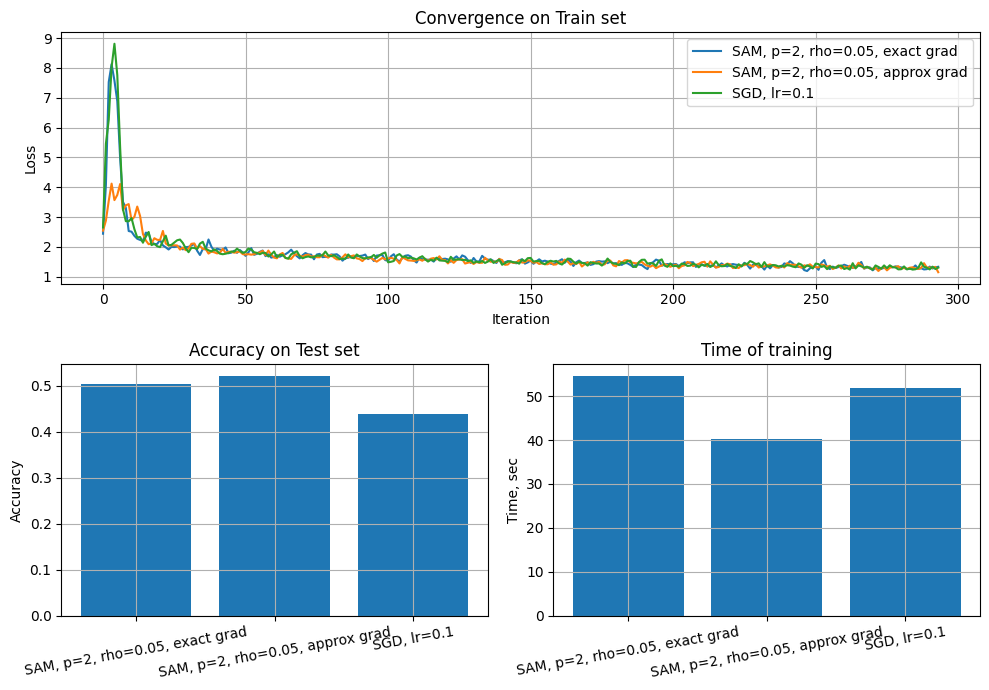

In [26]:
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(2, 2)
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(history_sam_exact_grad, label="SAM, p=2, rho=0.05, exact grad")
ax0.plot(history_sam_approx_grad, label="SAM, p=2, rho=0.05, approx grad")
ax0.plot(history_sgd, label="SGD, lr=0.1")
ax0.legend(loc="best")
ax0.set_xlabel("Iteration")
ax0.set_ylabel("Loss")
ax0.set_title("Convergence on Train set")
ax0.grid()

ax1 = fig.add_subplot(gs[1, 0])
ax1.bar(
    [
        "SAM, p=2, rho=0.05, exact grad",
        "SAM, p=2, rho=0.05, approx grad",
        "SGD, lr=0.1",
    ],
    [acc_sam_exact_grad, acc_sam_approx_grad, acc_sgd],
)

ax1.set_ylabel("Accuracy")
ax1.set_xticks(ax1.get_xticks())
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=10)
ax1.set_title("Accuracy on Test set")
ax1.grid()

ax2 = fig.add_subplot(gs[1, 1])
ax2.bar(
    [
        "SAM, p=2, rho=0.05, exact grad",
        "SAM, p=2, rho=0.05, approx grad",
        "SGD, lr=0.1",
    ],
    [time_sam_exact_grad, time_sam_approx_grad, time_sgd],
)

ax2.set_ylabel("Time, sec")
ax2.set_xticks(ax2.get_xticks())
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=10)
ax2.set_title("Time of training")
ax2.grid()

plt.tight_layout()
plt.show()

Как видно из графиков, второй способ вычисления градиента работает быстрее и качественнее, чем первый, а также он быстрее, чем `SGD`

8. Ниже представлен код для оценки качества `SAM` на данных со случайными метками на трейне.

In [29]:
def get_noisy_data(random_labels_proportion: float) -> torch.utils.data.DataLoader:
    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_test
    )
    targets = torch.tensor(trainset.targets)
    indices = random.choices(
        range(len(targets)), k=int(random_labels_proportion * len(targets))
    )
    random_labels = torch.randint(0, 10, (len(indices),))
    targets[indices] = random_labels
    trainset.targets = targets.tolist()

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True)

    return train_loader


model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
train_loader = get_noisy_data(0.2)
history_noisy_1, acc_noisy_1, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
train_loader = get_noisy_data(0.4)
history_noisy_2, acc_noisy_2, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
train_loader = get_noisy_data(0.6)
history_noisy_3, acc_noisy_3, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

Files already downloaded and verified


100%|██████████| 20/20 [00:01<00:00, 13.95it/s, accuracy=0.537]


Files already downloaded and verified


100%|██████████| 20/20 [00:01<00:00, 14.35it/s, accuracy=0.475]


Files already downloaded and verified


100%|██████████| 20/20 [00:01<00:00, 13.96it/s, accuracy=0.437]


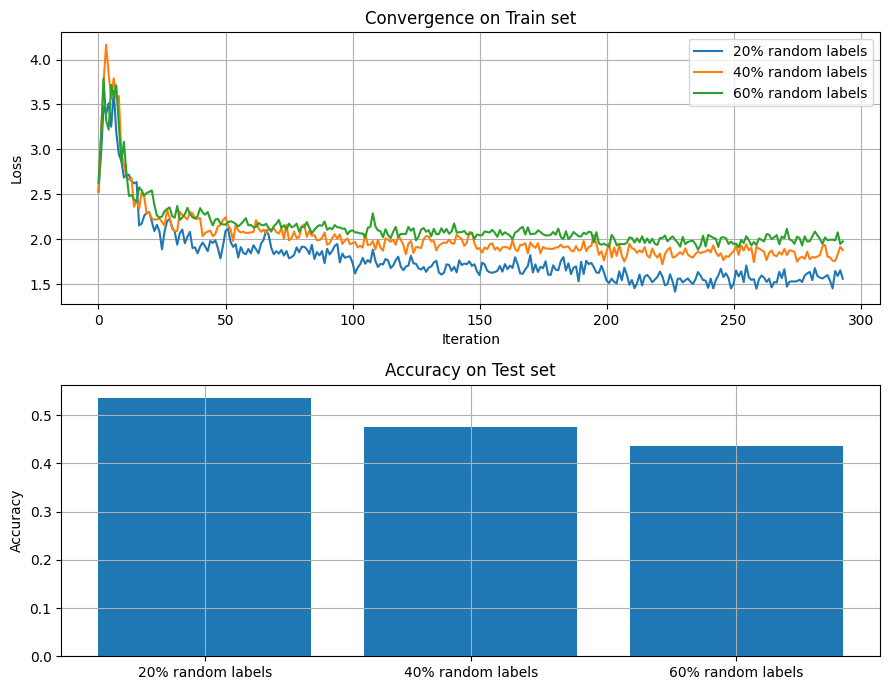

In [30]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9, 7))
ax[0].plot(history_noisy_1, label="20% random labels")
ax[0].plot(history_noisy_2, label="40% random labels")
ax[0].plot(history_noisy_3, label="60% random labels")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "20% random labels",
        "40% random labels",
        "60% random labels",
    ],
    [acc_noisy_1, acc_noisy_2, acc_noisy_3],
)

ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy on Test set")
ax[1].grid()

plt.tight_layout()
plt.show()

Как видно из графиков, SAM неплохо справляется с некачественными данными, но с ростом их пропорции качество падает.

9. Ниже представлен код оценивания качества `SAM` на данных с Adam по сравнению с `SAM` и `SGD`

In [35]:
model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.Adam, lr=0.001, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
history_adam, acc_adam, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

model = get_model(device)
optimizer = SAM(
    model.parameters(), optim.SGD, lr=0.1, p=1.5, rho=0.05, approx_grad=True
)
scheduler = ConstantScheduler(optimizer)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True)
history_sgd, acc_sgd, _ = test_optimizer(
    model,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
)
model = model.cpu()

100%|██████████| 20/20 [00:01<00:00, 13.61it/s, accuracy=0.52] 


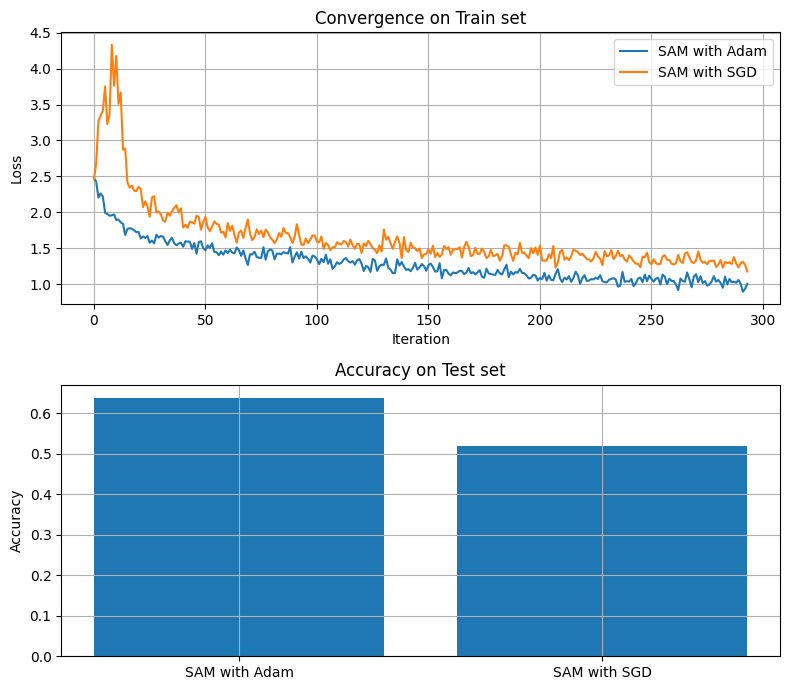

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
ax[0].plot(history_adam, label="SAM with Adam")
ax[0].plot(history_sgd, label="SAM with SGD")
ax[0].legend(loc="best")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Convergence on Train set")
ax[0].grid()

ax[1].bar(
    [
        "SAM with Adam",
        "SAM with SGD",
    ],
    [acc_adam, acc_sgd],
)
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy on Test set")
ax[1].grid()

plt.tight_layout()
plt.show()

Графики показывают, что `SAM` с `Adam` работает лучше, чем обычный с `SGD`, так что можно сделать вывод, что выбор `base_optimizer` влияет на качество работы `SAM`